In [48]:
from typing import TypedDict, Annotated
from langchain_core.messages import (HumanMessage, AIMessage, ToolMessage )
from langchain_core.tools import tool
from langgraph.graph import ( StateGraph, START, END)
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq

In [49]:
import os
from dotenv import load_dotenv

# Load API key from backend/.env
dotenv_path = os.path.abspath("../../../../.env")
load_dotenv(dotenv_path)

if not os.environ.get("GROQ_API_KEY"):
    print("Warning: GROQ_API_KEY not found in backend/.env")
else:
    print("GROQ_API_KEY loaded successfully.")

GROQ_API_KEY loaded successfully.


In [50]:
# Dummy product catalog
PRODUCTS = {
    "iphone_17": {
        "id": "iphone_17",
        "name": "iPhone 17",
        "category": "smartphone",
        "price": 79999
    },

    "airpods_4": {
        "id": "airpods_4",
        "name": "AirPods 4",
        "category": "audio",
        "price": 12999
    },

    "iphone_case": {
        "id": "iphone_case",
        "name": "iPhone 17 Silicone Case",
        "category": "accessory",
        "price": 1999
    },

    "screen_guard": {
        "id": "screen_guard",
        "name": "iPhone 17 Screen Guard",
        "category": "accessory",
        "price": 799
    }
}

In [ ]:
# Define the tool
@tool
def get_product_catalog() -> dict:
    """
    Get the list of all available products in the store catalog, 
    including their product IDs, names, categories, and prices.
    """
    return PRODUCTS


In [52]:
#  Cart state
cart = {
    "items": []
}
print(cart)

{'items': []}


In [53]:
#  add item to the cart (dynamic without hardcoded PRODUCTS dict)
def add_item_to_cart(product_id: str, quantity: int = 1, name: str = "", price: float = 0.0):
    display_name = name.strip() if name and name.strip() else product_id.replace("_", " ").replace("-", " ").title()
    
    # Check if already present in cart
    for item in cart["items"]:
        if item["product_id"].lower().strip() == product_id.lower().strip() or item["name"].lower().strip() == display_name.lower().strip():
            item["quantity"] += quantity
            if price > 0:
                item["price"] = price
            return {
                "success": True,
                "message": f"Updated quantity for {item['name']} in cart",
                "cart": get_cart_data()
            }

    # Add new item
    cart["items"].append({
        "product_id": product_id,
        "name": display_name,
        "price": float(price),
        "quantity": int(quantity)
    })

    return {
        "success": True,
        "message": f"{display_name} added to cart",
        "cart": get_cart_data()
    }


In [54]:
#  get cart item, item count, and total
def get_cart_data():
    total = 0.0
    for item in cart["items"]:
        total += item["price"] * item["quantity"]

    return {
        "items": cart["items"],
        "total": total,
        "item_count": sum(item["quantity"] for item in cart["items"])
    }


In [55]:
# Remove item from cart
def remove_item_from_cart(product_id: str):
    target = product_id.lower().strip()
    for item in cart["items"]:
        if item["product_id"].lower().strip() == target or item["name"].lower().strip() == target or target in item["name"].lower().strip():
            removed_name = item["name"]
            cart["items"].remove(item)
            return {
                "success": True,
                "message": f"{removed_name} removed from cart",
                "cart": get_cart_data()
            }

    return {
        "success": False,
        "error": f"Product '{product_id}' not present in cart",
        "cart": get_cart_data()
    }


In [56]:
#  custom tools creating for cart

# add item to cart tool
@tool
def add_to_cart(product_id: str, quantity: int = 1, name: str = "", price: float = 0.0) -> dict:
    """
    Add a product to the customer's cart.

    Args:
        product_id: The ID or name of the product (e.g. 'airpods_4', 'iphone_17', or 'AirPods').
        quantity: Quantity of the product to add (default is 1).
        name: Optional display name of the product.
        price: Optional price of the product (if known from product lookup).
    """
    return add_item_to_cart(product_id, quantity, name, price)

#  get cart items tool
@tool
def get_cart() -> dict:
    """
    Get the customer's current cart items, total quantity, and total price.
    """
    return get_cart_data()

#  remove cart item tool
@tool
def remove_from_cart(product_id: str) -> dict:
    """
    Remove a product from the customer's cart by product_id or product name.

    Args:
        product_id: The ID or name of the product to remove.
    """
    return remove_item_from_cart(product_id)


In [57]:
UPSELL_RULES = {
    "iphone_17": [
        "airpods_4",
        "iphone_case",
        "screen_guard"
    ]
}

In [58]:
# traversing the UPSELL_RULES dict
def get_upsell_recommendations(product_id: str):

    recommended_ids = UPSELL_RULES.get(product_id, [])

    recommendations = []

    for pid in recommended_ids:

        product = PRODUCTS.get(pid)

        if product:
            recommendations.append({
                "product_id": product["id"],
                "name": product["name"],
                "price": product["price"]
            })

    return {
        "product_id": product_id,
        "recommendations": recommendations
    }

In [ ]:
#  upsell custom tool
@tool
def get_upsell_products(product_id: str):
    """
    Find complementary products that can be offered to the customer.

    Use this when the customer asks for recommendations,
    additional products, or when an appropriate upsell
    opportunity exists.
    """

    return get_upsell_recommendations(product_id)

In [60]:
project_root = os.path.abspath(os.path.join(notebook_dir, "../../../../"))
print(project_root)

c:\Users\ps302\OneDrive\Desktop\Razorpay\backend


In [ ]:
# # Import the query functions from the store manager llm query pipeline
# import os
# import sys

# # Find backend/merchant_knowledge directory relative to this notebook
# notebook_dir = os.path.abspath("")
# project_root = os.path.abspath(os.path.join(notebook_dir, "../../../../"))
# if project_root not in sys.path:
#     sys.path.insert(0, project_root)

# from src.agents.store_manager_llm import query_knowledge_base, query_marketing_intelligence

# @tool
# def get_product_catalog(query: str) -> str:
#     """
#     Search or query the store's product catalog (including product names, specs, prices, categories, and reviews).
#     """

#     wiki_path = os.path.join(project_root, "merchant_knowledge")
#     result = query_knowledge_base(
#         query=query,
#         wiki_base_path=wiki_path,
#         merchant_id="23CE10086"
#     )
#     return result["answer"]

# @tool
# def get_upsell_products(product_id: str) -> str:
#     """
#     Find complementary products, upsell opportunities, discount campaigns...
#     """
#     # Fix: Remove extra "backend" from the path
#     wiki_path = os.path.join(project_root, "merchant_knowledge")
#     query = f"What complementary accessories, discounts, or upsell recommendations exist for {product_id}?"
#     result = query_marketing_intelligence(
#         query=query,
#         wiki_base_path=wiki_path,
#         merchant_id="23CE10086"
#     )
#     return result["answer"]


In [62]:
# all tools
tools = [add_to_cart, get_cart, remove_from_cart, get_upsell_products, get_product_catalog]


In [63]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [64]:
#  tool binding to the llm
llm_with_tools = llm.bind_tools(tools)

In [65]:
# Prompt
SYSTEM_PROMPT = """
You are the Merchant Commerce Agent.

You are responsible for handling customer shopping requests.

You have access to commerce tools.

Rules:

1. Never claim that a product was added unless add_to_cart
   successfully confirms it.

2. Never directly modify the cart yourself.

3. Use get_cart when you need current cart information.

4. Use get_upsell_products when the customer asks for
   recommendations or when an appropriate complementary
   product can be suggested.

5. Do not invent products.

6. Keep responses concise and commerce-focused.

7. If a tool fails, clearly tell the customer that the
   requested operation could not be completed.

8. MUST: Do not add the item to the cart until and unless customer ask to do, if he is asking about the product just tell it  where you have or not,
    and then ask him if he would like it to be added to the cart and along with it recommend the items that this inventory have
"""

In [66]:
class CommerceState(TypedDict):

    messages: Annotated[ list, add_messages ]

""" later add ons
user_id
merchant_id
cart
payment_context
policy_context
"""

' later add ons\nuser_id\nmerchant_id\ncart\npayment_context\npolicy_context\n'

In [67]:
def merchant_llm_node(state: CommerceState):

    messages = state["messages"]

    system_message = {
        "role": "system",
        "content": SYSTEM_PROMPT
    }

    response = llm_with_tools.invoke(
        [system_message] + messages
    )

    return {
        "messages": [response]
    }

    

In [68]:
tool_node = ToolNode(tools)

In [69]:
graph = StateGraph(CommerceState)

# nodes
graph.add_node("merchant_llm", merchant_llm_node )
graph.add_node( "tools", tool_node )

# edges
graph.add_edge(START, "merchant_llm" )
graph.add_conditional_edges("merchant_llm", tools_condition)
graph.add_edge("tools", "merchant_llm")


workflow = graph.compile()

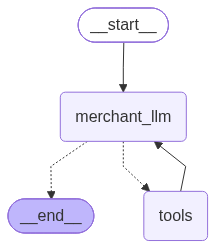

In [70]:
workflow

In [71]:
messages = []

In [72]:
print(cart)

{'items': []}


In [73]:
messages.append(
    HumanMessage(content="I want the iPhone 17.") 
    )

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

We don’t have an iPhone 17 in our catalog. The newest iPhone models we carry are the **iPhone 15** and **iPhone 15 Pro**.

Would you like more details on either of those models, or would you like to add one to your cart? I can also suggest compatible accessories we have available.


In [74]:
messages.append(
    HumanMessage(content="what are the headphones available in your shop.") 
    )

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

We have two headphone options:

| Product | Type | Price | Rating |
|---|---|---|---|
| Sony WH‑1000XM5 | Over‑ear | 29,990 INR | 4.7 / 5 |
| Apple AirPods Pro 2 | True‑wireless earbuds | 24,900 INR | 4.5 / 5 |

Would you like more details on either model, or should I add one to your cart? I can also suggest complementary accessories we have in stock.


In [75]:
messages.append(
    HumanMessage(
        content="add apple Airpods pro 2 to my cart for now"
    )
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]

print(result["messages"][-1].content)

Your Apple AirPods Pro 2 have been added to the cart (₹24,900).

Would you like to see any other products, add more items, or proceed to checkout? Let me know how I can help next.


In [76]:
print(cart)

{'items': [{'product_id': 'apple_airpods_pro_2', 'name': 'Apple AirPods Pro 2', 'price': 24900.0, 'quantity': 1}]}


In [77]:
messages.append(HumanMessage(
        content="Add the AirPod to the cart and I phone 17 to the cart")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

Your Apple AirPods Pro 2 are already in the cart (₹24,900).

Unfortunately, we don’t have an **iPhone 17** in our catalog, so it can’t be added to the cart. We do have the latest iPhone models—**iPhone 15** and **iPhone 15 Pro**—if you’d like to consider one of those instead. Let me know if you’d like details or to add either of them to your cart.


In [78]:
messages.append(HumanMessage(
        content="Show the whats is in my cart")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

**Your Cart**

| Product | Quantity | Unit Price | Subtotal |
|---|---|---|---|
| Apple AirPods Pro 2 | 1 | ₹24,900 | ₹24,900 |

**Total:** ₹24,900

Let me know if you’d like to add anything else, remove an item, or proceed to checkout.


In [79]:
print("🛒 Shopping Cart:")
print("-" * 65)
print(f"{'Product Name':<30} | {'Price (INR)':<12} | {'Qty':<5} | {'Subtotal':<10}")
print("-" * 65)

grand_total = 0
for item in cart.get("items", []):
    name = item["name"]
    price = item["price"]
    qty = item["quantity"]
    subtotal = price * qty
    grand_total += subtotal
    print(f"{name:<30} | {price:>11,} | {qty:>5} | {subtotal:>10,}")

print("-" * 65)
print(f"{'Grand Total':<30} | {'':<12} | {'':<5} | {grand_total:>10,}")
print("-" * 65)


🛒 Shopping Cart:
-----------------------------------------------------------------
Product Name                   | Price (INR)  | Qty   | Subtotal  
-----------------------------------------------------------------
Apple AirPods Pro 2            |    24,900.0 |     1 |   24,900.0
-----------------------------------------------------------------
Grand Total                    |              |       |   24,900.0
-----------------------------------------------------------------


In [80]:
for message in result["messages"]:
    if message.content:
        print(message.content)


I want the iPhone 17.
**Answer**

The store’s knowledge base does not contain any information about an **iPhone 17**. The only iPhone models currently documented are the **iPhone 15** and **iPhone 15 Pro** (see the product pages for those devices)【knowledge/products/iphone-15.md】【knowledge/products/iphone-15-pro.md】.

If you are looking for a newer Apple smartphone, you might consider the latest models we have listed (iPhone 15 and iPhone 15 Pro). Otherwise, please let us know if you need details on any of the available products or assistance with something else.
I’m sorry, but the store knowledge base does not contain any information about complementary accessories, discounts, or upsell recommendations for **iPhone 15**. The available wiki pages only list the product itself without details on related promotions or suggested add‑ons.
I’m sorry, but our store knowledge base does not contain any information about iPhone 15 cases. The available product pages only cover the iPhone 15 and i

In [81]:
print("🛒 Shopping Cart:")
print("-" * 65)
print(f"{'Product Name':<30} | {'Price (INR)':<12} | {'Qty':<5} | {'Subtotal':<10}")
print("-" * 65)

grand_total = 0
for item in cart.get("items", []):
    name = item["name"]
    price = item["price"]
    qty = item["quantity"]
    subtotal = price * qty
    grand_total += subtotal
    print(f"{name:<30} | {price:>11,} | {qty:>5} | {subtotal:>10,}")

print("-" * 65)
print(f"{'Grand Total':<30} | {'':<12} | {'':<5} | {grand_total:>10,}")
print("-" * 65)


🛒 Shopping Cart:
-----------------------------------------------------------------
Product Name                   | Price (INR)  | Qty   | Subtotal  
-----------------------------------------------------------------
Apple AirPods Pro 2            |    24,900.0 |     1 |   24,900.0
-----------------------------------------------------------------
Grand Total                    |              |       |   24,900.0
-----------------------------------------------------------------


In [82]:
messages.append(HumanMessage(
        content="any recommendations ")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

Here are a few items that pair well with your Apple AirPods Pro 2:

| Recommendation | Why it fits |
|---|---|
| **iPad Air M2** (Apple tablet) | Seamless integration with AirPods Pro 2 for iPadOS features like spatial audio and quick pairing. |
| **Samsung Galaxy Tab S9** | Great for Android users who still want high‑quality audio from the AirPods Pro 2 via Bluetooth. |
| **Sony WH‑1000XM5** (over‑ear headphones) | If you ever need a backup or a different listening experience, these offer top‑tier noise‑cancellation. |

Let me know if you’d like details on any of these or want to add one to your cart.
